# Retail Banking Risk & Fraud Analytics Platform

## Phase 3: Exploratory Data Analysis (EDA)

### Objective

Explore fraud patterns, customer behaviour, transaction characteristics, and feature relationships to discover business insights before building machine learning models.

**Author:** Md Aaris

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

In [1]:
import pandas as pd
import numpy as np

dtypes = {
    "TransactionID": "int32",
    "isFraud": "int8",
    "TransactionDT": "int32",
    "TransactionAmt": "float32"
}

transaction = pd.read_csv(
    "../data/ieee_fraud/train_transaction.csv",
    dtype=dtypes,
    low_memory=True
)

identity = pd.read_csv(
    "../data/ieee_fraud/train_identity.csv",
    low_memory=True
)

In [2]:
data = transaction.merge(
    identity,
    on="TransactionID",
    how="left"
)

print(data.shape)

(590540, 434)


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float32(1), float64(398), int32(2), int64(1), int8(1), object(31)
memory usage: 1.9+ GB


In [4]:
print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 590540
Columns : 434


In [5]:
missing = data.isnull().sum().sort_values(ascending=False)

missing.head(20)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_04    524216
id_03    524216
D6       517353
id_33    517251
id_09    515614
dtype: int64

In [6]:
data["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [8]:
data["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

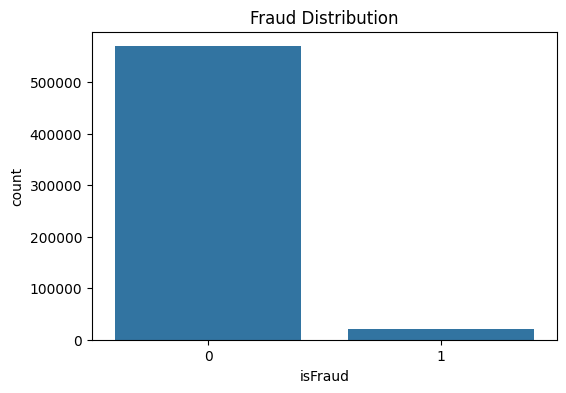

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="isFraud", data=data)
plt.title("Fraud Distribution")
plt.show()

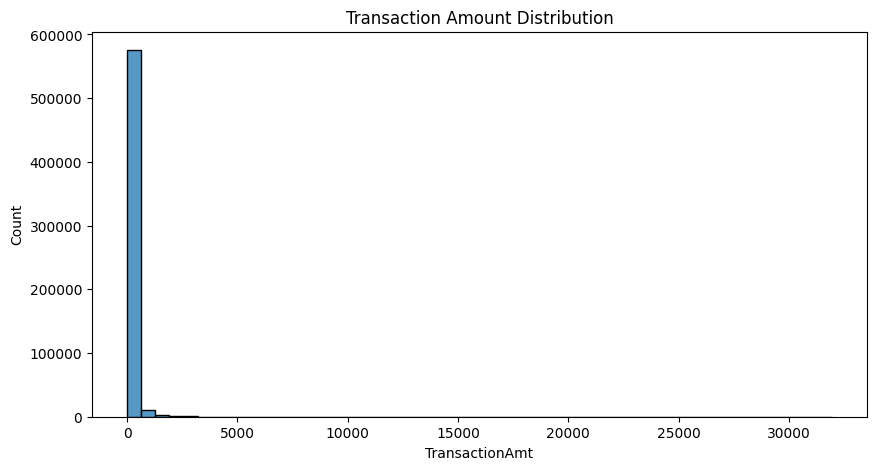

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(data["TransactionAmt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

# Initial EDA Observations

### Fraud Distribution

- The dataset is highly imbalanced.
- Approximately 96.5% of transactions are legitimate.
- Only about 3.5% of transactions are fraudulent.
- This indicates that fraud detection is an imbalanced classification problem.

### Transaction Amount Distribution

- Most transactions have relatively small transaction amounts.
- A few transactions have extremely high values, creating a long right tail.
- The distribution is positively (right) skewed.
- Outliers are present and may require transformation or robust scaling before model training.

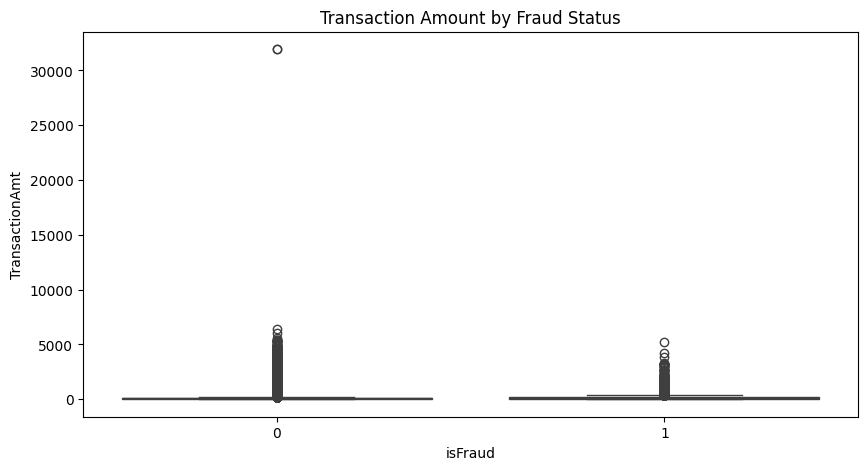

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x="isFraud", y="TransactionAmt", data=data)
plt.title("Transaction Amount by Fraud Status")
plt.show()

In [12]:
fraud_percent = data["isFraud"].value_counts(normalize=True) * 100
fraud_percent

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [13]:
missing = data.isnull().mean() * 100

missing = missing.sort_values(ascending=False)

missing.head(20)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64

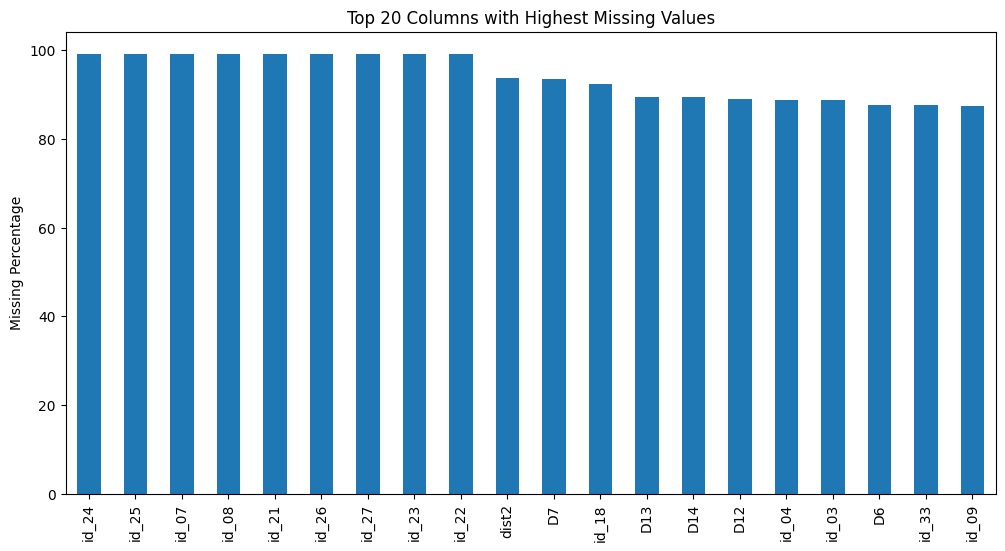

In [14]:
plt.figure(figsize=(12,6))
missing.head(20).plot(kind="bar")
plt.title("Top 20 Columns with Highest Missing Values")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=90)
plt.show()

In [15]:
corr = data[
    ["isFraud", "TransactionAmt", "TransactionDT"]
].corr()

corr

,isFraud,TransactionAmt,TransactionDT
isFraud,1.000000,0.01132,0.013103
TransactionAmt,0.011320,1.00000,0.011920
TransactionDT,0.013103,0.01192,1.000000


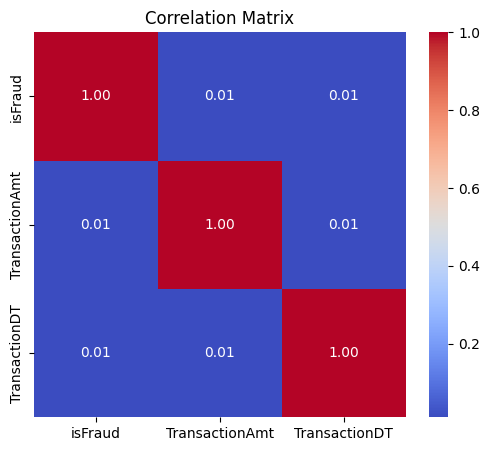

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Correlation Observations

- Transaction Amount shows a very weak correlation with fraud.
- Transaction Time also has a weak linear relationship with fraud.
- No strong linear correlation exists among these variables.
- Fraud detection will require multiple features instead of relying on a single variable.

In [17]:
fraud_corr = (
    data.corr(numeric_only=True)["isFraud"]
    .sort_values(ascending=False)
)

fraud_corr.head(20)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64

In [18]:
fraud_corr.tail(20)

D4      -0.067216
V36     -0.069875
V11     -0.071950
D10     -0.072002
V10     -0.074658
V35     -0.077116
D15     -0.077519
D2      -0.083583
id_07   -0.084768
V70     -0.100900
V30     -0.103088
V69     -0.104521
V91     -0.105453
V29     -0.107852
V90     -0.110168
V49     -0.110920
V48     -0.115786
id_01   -0.120099
D7      -0.127199
D8      -0.142636
Name: isFraud, dtype: float64

In [19]:
data["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

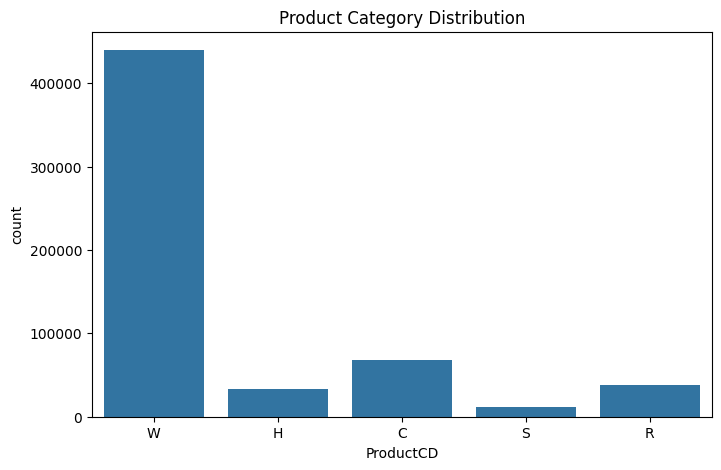

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x="ProductCD", data=data)
plt.title("Product Category Distribution")
plt.show()

In [21]:
data.groupby("ProductCD")["isFraud"].mean().sort_values(ascending=False) * 100

ProductCD
C    11.687269
S     5.899553
H     4.766231
R     3.782594
W     2.039939
Name: isFraud, dtype: float64

In [22]:
data["card4"].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

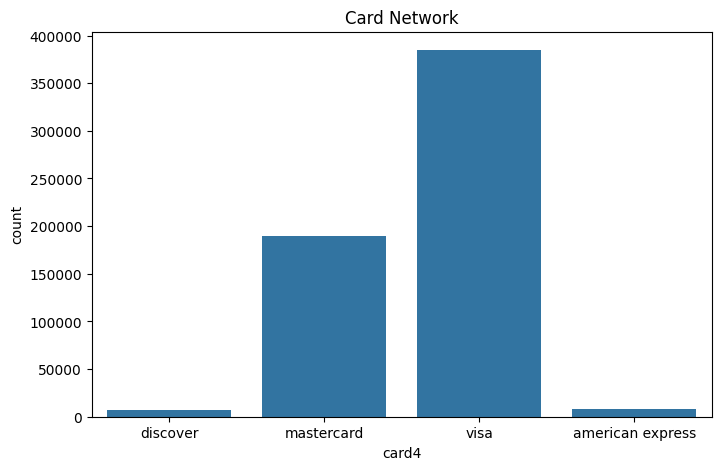

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x="card4", data=data)
plt.title("Card Network")
plt.show()

In [24]:
data.groupby("card4")["isFraud"].mean().sort_values(ascending=False) * 100

card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64

In [25]:
data["P_emaildomain"].value_counts().head(15)

P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
bellsouth.net      1909
Name: count, dtype: int64

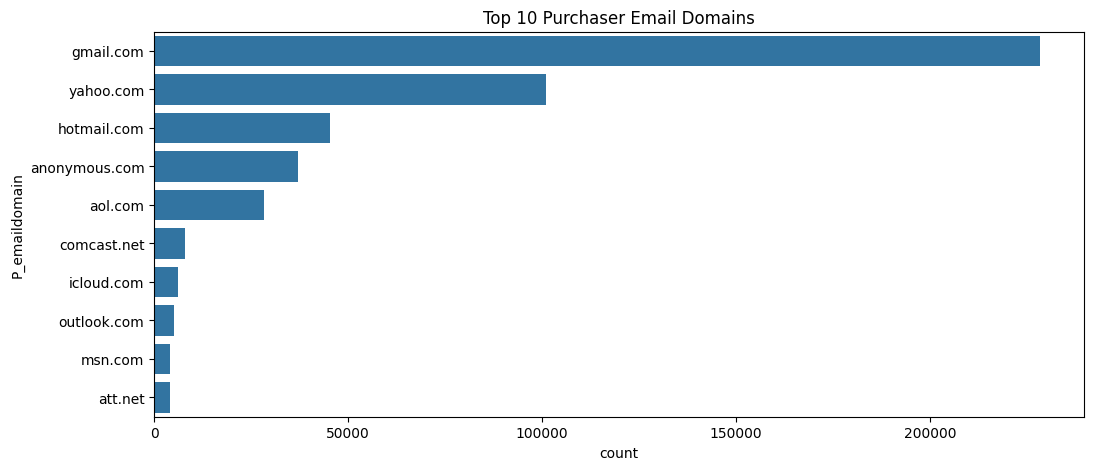

In [26]:
plt.figure(figsize=(12,5))
sns.countplot(
    y="P_emaildomain",
    data=data,
    order=data["P_emaildomain"].value_counts().head(10).index
)
plt.title("Top 10 Purchaser Email Domains")
plt.show()

# Categorical Feature Observations

- Product categories are not equally distributed.
- Fraud rate differs across ProductCD categories.
- Visa and Mastercard dominate the card network distribution.
- Fraud percentages vary slightly across different card networks.
- Gmail, Yahoo, and AOL are among the most common purchaser email domains.
- Categorical variables may provide useful predictive information after encoding.

In [27]:
card_cols = ["card1","card2","card3","card5"]

data[card_cols].describe()

,card1,card2,card3,card5
count,590540.000000,581607.000000,588975.000000,586281.000000
mean,9898.734658,362.555488,153.194925,199.278897
std,4901.170153,157.793246,11.336444,41.244453
min,1000.000000,100.000000,100.000000,100.000000
25%,6019.000000,214.000000,150.000000,166.000000
50%,9678.000000,361.000000,150.000000,226.000000
75%,14184.000000,512.000000,150.000000,226.000000
max,18396.000000,600.000000,231.000000,237.000000


In [28]:
data["TransactionAmt"].describe()

count    590540.000000
mean        135.027161
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

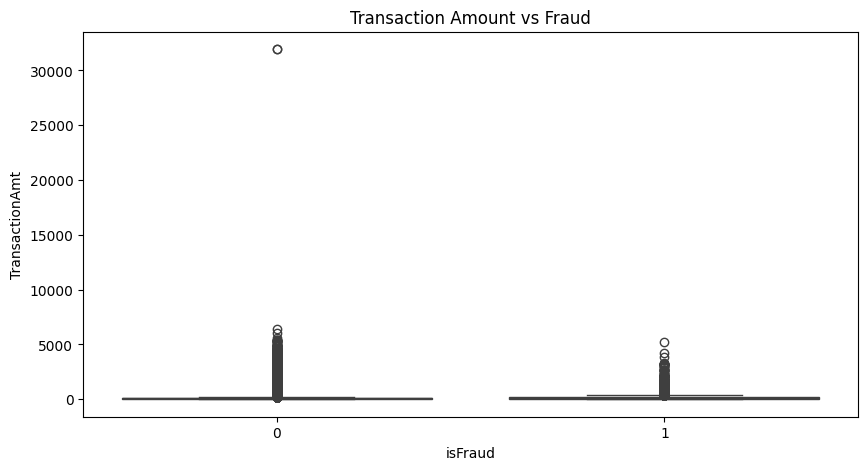

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="isFraud",
    y="TransactionAmt",
    data=data
)

plt.title("Transaction Amount vs Fraud")
plt.show()

In [30]:
data["TransactionDT"].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

# Numerical Feature Observations

- Transaction Amount is highly right-skewed with several extreme outliers.
- Fraudulent transactions generally show different amount distributions compared to legitimate transactions.
- Card-related features contain a wide range of customer information.
- Transaction time spans a long duration and may help identify temporal fraud patterns.
- Numerical features will require scaling or transformation before machine learning.

# Phase 3 Conclusion

## Completed

- Performed Exploratory Data Analysis on the merged dataset.
- Studied fraud distribution and class imbalance.
- Analyzed transaction amount distribution.
- Examined missing-value patterns.
- Investigated numerical and categorical features.
- Identified important features correlated with fraud.

## Key Findings

- Fraud cases represent only about 3.5% of all transactions.
- The dataset is highly imbalanced.
- Several V-series features show stronger correlation with fraud.
- Many columns contain substantial missing values.
- Product category, card network, and email domains provide useful business insights.
- Numerical features contain outliers that should be handled before model training.

## Next Phase

The next notebook will focus on Feature Engineering, feature selection, and preparing the final dataset for machine learning models.

In [31]:
data.to_pickle("../outputs/merged_data.pkl")

# Phase 4: Feature Engineering

## Objective

Create meaningful features from the existing data to improve machine learning model performance.

In [32]:
data["TransactionHour"] = (data["TransactionDT"] // 3600) % 24
data["TransactionDay"] = data["TransactionDT"] // (24 * 3600)
data["TransactionWeek"] = data["TransactionDay"] // 7

data[
    ["TransactionDT",
     "TransactionHour",
     "TransactionDay",
     "TransactionWeek"]
].head()

,TransactionDT,TransactionHour,TransactionDay,TransactionWeek
0,86400,0,1,0
1,86401,0,1,0
2,86469,0,1,0
3,86499,0,1,0
4,86506,0,1,0


In [33]:
data["P_email_prefix"] = data["P_emaildomain"].fillna("unknown").str.split(".").str[0]
data["R_email_prefix"] = data["R_emaildomain"].fillna("unknown").str.split(".").str[0]

data[
    ["P_emaildomain",
     "P_email_prefix",
     "R_emaildomain",
     "R_email_prefix"]
].head()

,P_emaildomain,P_email_prefix,R_emaildomain,R_email_prefix
0,NaN,unknown,NaN,unknown
1,gmail.com,gmail,NaN,unknown
2,outlook.com,outlook,NaN,unknown
3,yahoo.com,yahoo,NaN,unknown
4,gmail.com,gmail,NaN,unknown


In [34]:
data["Card_ID"] = (
    data["card1"].astype(str) + "_" +
    data["card2"].astype(str) + "_" +
    data["card3"].astype(str) + "_" +
    data["card5"].astype(str)
)

data["Card_ID"].head()

0      13926_nan_150.0_142.0
1     2755_404.0_150.0_102.0
2     4663_490.0_150.0_166.0
3    18132_567.0_150.0_117.0
4     4497_514.0_150.0_102.0
Name: Card_ID, dtype: object

In [35]:
data["TransactionAmt_Log"] = np.log1p(data["TransactionAmt"])

data[
    ["TransactionAmt",
     "TransactionAmt_Log"]
].head()

,TransactionAmt,TransactionAmt_Log
0,68.5,4.241327
1,29.0,3.401197
2,59.0,4.094345
3,50.0,3.931826
4,50.0,3.931826


In [36]:
new_features = [
    "TransactionHour",
    "TransactionDay",
    "TransactionWeek",
    "P_email_prefix",
    "R_email_prefix",
    "Card_ID",
    "TransactionAmt_Log"
]

data[new_features].head()

,TransactionHour,TransactionDay,TransactionWeek,P_email_prefix,R_email_prefix,Card_ID,TransactionAmt_Log
0,0,1,0,unknown,unknown,13926_nan_150.0_142.0,4.241327
1,0,1,0,gmail,unknown,2755_404.0_150.0_102.0,3.401197
2,0,1,0,outlook,unknown,4663_490.0_150.0_166.0,4.094345
3,0,1,0,yahoo,unknown,18132_567.0_150.0_117.0,3.931826
4,0,1,0,gmail,unknown,4497_514.0_150.0_102.0,3.931826


# Feature Engineering Observations

- Extracted hour, day and week from transaction time.
- Extracted purchaser and recipient email prefixes.
- Created a unique Card_ID by combining card information.
- Applied logarithmic transformation to transaction amount.
- These engineered features may improve fraud detection performance.

# Feature Selection

In [37]:
missing = data.isnull().mean() * 100

drop_cols = missing[missing > 90].index

print("Columns to Drop:", len(drop_cols))
drop_cols[:20]

Columns to Drop: 12


Index(['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23',
       'id_24', 'id_25', 'id_26', 'id_27'],
      dtype='object')

In [38]:
data_fs = data.drop(columns=drop_cols)

print(data.shape)
print(data_fs.shape)

(590540, 441)
(590540, 429)


In [39]:
constant_cols = [
    col for col in data_fs.columns
    if data_fs[col].nunique(dropna=False) <= 1
]

print("Constant Columns:", len(constant_cols))
constant_cols

Constant Columns: 0


[]

In [40]:
data_fs = data_fs.drop(columns=constant_cols)

print(data_fs.shape)

(590540, 429)


In [41]:
print("Final Features:", data_fs.shape[1])

data_fs.head()

Final Features: 429


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_38,DeviceType,DeviceInfo,TransactionHour,TransactionDay,TransactionWeek,P_email_prefix,R_email_prefix,Card_ID,TransactionAmt_Log
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,0,1,0,unknown,unknown,13926_nan_150.0_142.0,4.241327
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,0,1,0,gmail,unknown,2755_404.0_150.0_102.0,3.401197
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,0,1,0,outlook,unknown,4663_490.0_150.0_166.0,4.094345
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,0,1,0,yahoo,unknown,18132_567.0_150.0_117.0,3.931826
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,T,mobile,SAMSUNG SM-G892A Build/NRD90M,0,1,0,gmail,unknown,4497_514.0_150.0_102.0,3.931826


# Feature Selection Observations

- Removed columns having more than 90% missing values.
- Removed constant-value features.
- Reduced dimensionality of the dataset.
- The resulting dataset is more suitable for machine learning models.

# Phase 5: Machine Learning Preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

In [2]:
dtypes = {
    "TransactionID": "int32",
    "isFraud": "int8",
    "TransactionDT": "int32",
    "TransactionAmt": "float32"
}

transaction = pd.read_csv(
    "../data/ieee_fraud/train_transaction.csv",
    dtype=dtypes,
    low_memory=True
)

identity = pd.read_csv(
    "../data/ieee_fraud/train_identity.csv",
    low_memory=True
)

data = transaction.merge(
    identity,
    on="TransactionID",
    how="left"
)

print(data.shape)

(590540, 434)


In [3]:
data["TransactionHour"] = (data["TransactionDT"] // 3600) % 24
data["TransactionDay"] = (data["TransactionDT"] // 86400) % 7
data["TransactionWeek"] = (data["TransactionDT"] // (86400 * 7))

data["P_email_prefix"] = (
    data["P_emaildomain"]
    .fillna("unknown")
    .astype(str)
    .str.split(".")
    .str[0]
)

data["R_email_prefix"] = (
    data["R_emaildomain"]
    .fillna("unknown")
    .astype(str)
    .str.split(".")
    .str[0]
)

data["Card_ID"] = (
    data["card1"].astype(str) + "_" +
    data["card2"].astype(str)
)

data["TransactionAmt_Log"] = np.log1p(data["TransactionAmt"])

In [4]:
missing = data.isnull().mean() * 100

drop_cols = missing[missing > 90].index

data_fs = data.drop(columns=drop_cols)

constant_cols = [
    col for col in data_fs.columns
    if data_fs[col].nunique(dropna=False) == 1
]

data_fs = data_fs.drop(columns=constant_cols)

print(data_fs.shape)

(590540, 429)


In [5]:
data_fs.to_pickle("../outputs/final_dataset.pkl")

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [6]:
data_fs = pd.read_pickle("../outputs/final_dataset.pkl")

# Load Final Dataset

In [7]:
data = pd.read_pickle("../outputs/final_dataset.pkl")

print(data.shape)
data.head()

(590540, 429)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_19,id_20,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,TransactionHour,TransactionDay,TransactionWeek,P_email_prefix,R_email_prefix,Card_ID,TransactionAmt_Log
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,unknown,unknown,13926_nan,4.241327
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,gmail.com,NaN,1.0,1

# Check Missing Values

In [8]:
print(data.isnull().sum().sum())

108604268


# Handle Missing Values

In [11]:
# Numerical columns
num_cols = data.columns[data.dtypes != "object"]

# Fill numerical missing values one column at a time
for col in num_cols:
    if data[col].isnull().any():
        data[col].fillna(data[col].median(), inplace=True)

# Categorical columns
cat_cols = data.columns[data.dtypes == "object"]

# Fill categorical missing values
for col in cat_cols:
    if data[col].isnull().any():
        data[col].fillna("Unknown", inplace=True)

print("Missing Values Left:", data.isnull().sum().sum())

C:\Users\MD AARIS\AppData\Local\Temp\ipykernel_17140\3351086771.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\MD AARIS\AppData\Local\Temp\ipykernel_17140\3351086771.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Missing Values Left: 0


# Encode Categorical Variables

In [13]:
from sklearn.preprocessing import LabelEncoder

cat_cols = data.columns[data.dtypes == "object"]

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le

print("Encoded Columns:", len(cat_cols))

ModuleNotFoundError: No module named 'sklearn'

In [1]:
from sklearn.preprocessing import LabelEncoder

print("Scikit-learn imported successfully!")

Scikit-learn imported successfully!


In [3]:
import pandas as pd

data = pd.read_pickle("../outputs/final_dataset.pkl")

print(data.shape)

(590540, 429)


In [4]:
from sklearn.preprocessing import LabelEncoder

# Numerical columns
num_cols = data.columns[data.dtypes != "object"]

for col in num_cols:
    if data[col].isnull().any():
        data[col].fillna(data[col].median(), inplace=True)

# Categorical columns
cat_cols = data.columns[data.dtypes == "object"]

for col in cat_cols:
    if data[col].isnull().any():
        data[col].fillna("Unknown", inplace=True)

# Encode
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le

print("Missing Values:", data.isnull().sum().sum())
print("Encoded Columns:", len(cat_cols))

C:\Users\MD AARIS\AppData\Local\Temp\ipykernel_13948\3006800172.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\MD AARIS\AppData\Local\Temp\ipykernel_13948\3006800172.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Missing Values: 0
Encoded Columns: 32
